In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import kagglehub



In [3]:
import os
import kagglehub

try:
    path = kagglehub.dataset_download("tinashri/brain-tumor-dataset-includes-the-mask-and-images")
    print("Veri seti yolu:", path)
except Exception as e:
    print(f"Bağlantı hatası devam ediyor: {e}")

100%|████████████████████████████████████████████████| 312M/312M [00:36<00:00, 8.93MB/s]

Extracting files...


Veri seti yolu: /home/sero/.cache/kagglehub/datasets/tinashri/brain-tumor-dataset-includes-the-mask-and-images/versions/2


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import glob

class BrainTumorSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(images_dir, '*.*')))
        self.mask_paths = sorted(glob.glob(os.path.join(masks_dir, '*.*')))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        
        image = transforms.functional.resize(image, (224, 224))
        mask = transforms.functional.resize(mask, (224, 224))
        
        image = transforms.functional.to_tensor(image)
        mask = transforms.functional.to_tensor(mask)
        
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        mask = (mask > 0.0).float() 
        
        return image, mask

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader 
import os
import glob
from PIL import Image

data_dir = "data"

class BrainTumorSegmentationDataset(Dataset):
    def __init__(self, base_dir, split='train'):
        
        self.img_dir = os.path.join(base_dir, 'images')
        self.mask_dir = os.path.join(base_dir, 'masks') 
       
        self.image_paths = sorted(glob.glob(os.path.join(self.img_dir, '*.*')))
        self.mask_paths = sorted(glob.glob(os.path.join(self.mask_dir, '*.*')))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        
        image = transforms.functional.resize(image, (224, 224))
        mask = transforms.functional.resize(mask, (224, 224))
        
        import random
        if random.random() > 0.5:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)
        if random.random() > 0.5:
            image = transforms.functional.vflip(image)
            mask = transforms.functional.vflip(mask)
        # --------------------------------------------------------------------------------
        
        image = transforms.functional.to_tensor(image)
        mask = transforms.functional.to_tensor(mask)
        
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        mask = (mask > 0.0).float() 
        
        return image, mask
# ----------------------------------------------------

image_datasets = {
    'train': BrainTumorSegmentationDataset(data_dir, split='train'),
    'val':   BrainTumorSegmentationDataset(data_dir, split='val'),
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=8, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(f"Device: {device}")
print(f"Eğitim Görsel/Maske Çifti: {dataset_sizes['train']} | Doğrulama Görsel/Maske Çifti: {dataset_sizes['val']}")

Device: cuda
Eğitim Görsel/Maske Çifti: 3064 | Doğrulama Görsel/Maske Çifti: 3064


In [13]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
    def double_conv(in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c), 
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c), 
            nn.ReLU(inplace=True)
        )
            
        self.down1 = double_conv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        
        self.bottleneck = double_conv(128, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up1 = double_conv(128, 64)
        
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)
        c2 = self.down2(p1)
        p2 = self.pool2(c2)
        
        b = self.bottleneck(p2)
        
        u2 = self.up2(b)
        u2 = torch.cat([u2, c2], dim=1)
        c3 = self.conv_up2(u2)
        
        u1 = self.up1(c3)
        u1 = torch.cat([u1, c1], dim=1)
        c4 = self.conv_up1(u1)
        
        return self.final_conv(c4)

model = UNet(in_channels=3, out_channels=1).to(device)
print("U-Net Modeli segmentasyon için başarıyla yüklendi.")

U-Net Modeli segmentasyon için başarıyla yüklendi.


In [23]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        
    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)
        
        sig_preds = torch.sigmoid(preds)
        intersection = (sig_preds * targets).sum(dim=(2, 3))
        union = sig_preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_loss = 1 - ((2. * intersection + 1e-8) / (union + 1e-8)).mean()
        
        return bce_loss + dice_loss # İki kaybın toplamı
criterion = BCEDiceLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("U-Net için BCEDiceLoss ve optimizer hazır.")

U-Net için BCEDiceLoss ve optimizer hazır.


In [24]:
import time
import copy
import torch
import gc 

gc.collect()
print("VRAM ve sistem önbelleği başarıyla temizlendi.")
# -------------------------------------------------------------

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_dice = 0.0  

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_dice = 0.0  # Doğruluk (Accuracy) yerine pikselsel Dice takibi

            for inputs, masks in dataloaders[phase]:
                inputs = inputs.to(device)
                masks = masks.to(device)
                optimizer.zero_grad()
            
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, masks)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
            
                running_loss += loss.item() * inputs.size(0)
                
                with torch.no_grad():
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                    intersection = (preds * masks).sum(dim=(2, 3))
                    union = preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3))

                    dice = (2. * intersection + 1e-8) / (union + 1e-8)
                    running_dice += dice.sum().item()

                del inputs, masks, outputs, loss
                if phase == 'train':
                    del preds, intersection, union, dice
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_dice = running_dice / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Dice: {epoch_dice:.4f}')
            
            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_dice > best_dice:
                    best_dice = epoch_dice
                    best_model_wts = copy.deepcopy(model.state_dict())
            
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        print() 
    time_elapsed = time.time() - since
    print(f'Eğitim tamamlandı: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En iyi doğrulama başarısı (Dice): {best_dice:.4f}')
    
    model.load_state_dict(best_model_wts)
    return model

if 'scheduler' not in globals():
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

VRAM ve sistem önbelleği başarıyla temizlendi.
Epoch 1/10
----------
train Loss: 0.8841 Dice: 0.2197
val Loss: 0.8305 Dice: 0.2634

Epoch 2/10
----------
train Loss: 0.8064 Dice: 0.2999
val Loss: 0.7491 Dice: 0.3583

Epoch 3/10
----------
train Loss: 0.7252 Dice: 0.3748
val Loss: 0.6713 Dice: 0.4218

Epoch 4/10
----------
train Loss: 0.6614 Dice: 0.4319
val Loss: 0.6193 Dice: 0.4678

Epoch 5/10
----------
train Loss: 0.6025 Dice: 0.4848
val Loss: 0.5494 Dice: 0.5362

Epoch 6/10
----------
train Loss: 0.5567 Dice: 0.5253
val Loss: 0.5185 Dice: 0.5593

Epoch 7/10
----------
train Loss: 0.5291 Dice: 0.5498
val Loss: 0.4976 Dice: 0.5824

Epoch 8/10
----------
train Loss: 0.4887 Dice: 0.5849
val Loss: 0.4609 Dice: 0.6088

Epoch 9/10
----------
train Loss: 0.4685 Dice: 0.6031
val Loss: 0.4438 Dice: 0.6240

Epoch 10/10
----------
train Loss: 0.4414 Dice: 0.6268
val Loss: 0.4135 Dice: 0.6519

Eğitim tamamlandı: 19m 39s
En iyi doğrulama başarısı (Dice): 0.6519


In [ ]:
#                        FINE TUNING                           #

In [14]:
import torch.optim as optim

model = model_ft 

optimizer = optim.Adam(model.parameters(), lr=0.00003)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("Mevcut ağırlıklar korundu. Öğrenme oranı hassas ayar (Fine-Tuning) için düşürüldü.")

model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=15)

NameError: name 'model_ft' is not defined

In [ ]:
Mevcut ağırlıklar korundu. Öğrenme oranı hassas ayar (Fine-Tuning) için düşürüldü.
Epoch 1/10
----------
train Loss: 0.0187 Dice: 0.7376
val Loss: 0.0184 Dice: 0.7437

Epoch 2/10
----------
train Loss: 0.0186 Dice: 0.7389
val Loss: 0.0184 Dice: 0.7373

Epoch 3/10
----------
train Loss: 0.0185 Dice: 0.7400
val Loss: 0.0183 Dice: 0.7422

Epoch 4/10
----------
train Loss: 0.0184 Dice: 0.7408
val Loss: 0.0184 Dice: 0.7482

Epoch 5/10
----------
train Loss: 0.0184 Dice: 0.7407
val Loss: 0.0181 Dice: 0.7433

Epoch 6/10
----------
train Loss: 0.0183 Dice: 0.7415
val Loss: 0.0181 Dice: 0.7415

Epoch 7/10
----------
train Loss: 0.0183 Dice: 0.7437
val Loss: 0.0180 Dice: 0.7459

Epoch 8/10
----------
train Loss: 0.0183 Dice: 0.7420
val Loss: 0.0182 Dice: 0.7481

Epoch 9/10
----------
train Loss: 0.0182 Dice: 0.7442
val Loss: 0.0179 Dice: 0.7468

Epoch 10/10
----------
train Loss: 0.0181 Dice: 0.7447

In [ ]:
model.eval()
with torch.no_grad():
    out = model(batch_t)
    # Çıktıyı 0 ile 1 arasına sıkıştırıp maskeye dönüştürüyoruz
    probabilities = torch.sigmoid(out)
    mask_prediction = (probabilities > 0.5).float() 
    
    # Eğer maskede 0.5'ten büyük değere sahip piksel sayısı belirli bir eşikten fazlaysa tümör vardır
    pixel_count = torch.sum(mask_prediction).item()
    
    if pixel_count > 50: # 50 pikselden fazla alan kaplıyorsa tümör var kabul et
        print(f"Tahmin: TÜMÖR TESPİT EDİLDİ ({pixel_count} piksel alan)")
    else:
        print("Tahmin: TÜMÖR BULUNAMADI (Sağlıklı)")

In [56]:
import torch

model_save_path = 'unet7447basari.pth'

if 'model_ft' in locals() or 'model_ft' in globals():
    torch.save(model_ft.state_dict(), model_save_path)
    print(f"Model '{model_save_path}' konumuna kaydedildi.")
else:
    print("Hata")


Model 'unet7447basari.pth' konumuna kaydedildi.


Model ve .pth ağırlıkları başarıyla yüklendi!


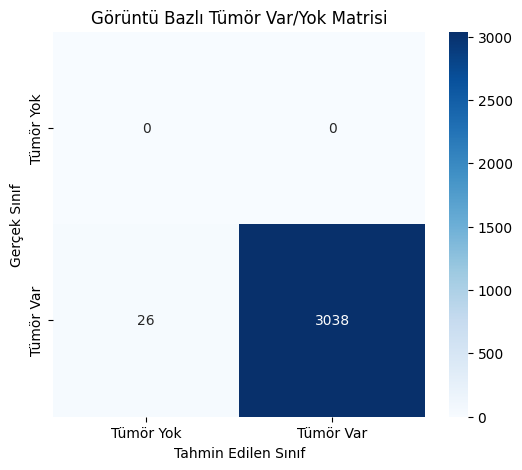

Matris 'confusion_matrix_image.png' adıyla klasörüne kaydedildi.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix

class U_Net_Uyumlu(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(U_Net_Uyumlu, self).__init__()
        
        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )
            
        self.down1 = double_conv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        
        self.bottleneck = double_conv(128, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up1 = double_conv(128, 64)
        
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)
        c2 = self.down2(p1)
        p2 = self.pool2(c2)
        
        b = self.bottleneck(p2)
        
        u2 = self.up2(b)
        u2 = torch.cat([u2, c2], dim=1)
        c3 = self.conv_up2(u2)
        
        u1 = self.up1(c3)
        u1 = torch.cat([u1, c1], dim=1)
        c4 = self.conv_up1(u1)
        
        return self.final_conv(c4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = U_Net_Uyumlu(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load("unet7447basari.pth", map_location=device))
print("Model ve .pth ağırlıkları başarıyla yüklendi!")

def create_confusion_matrix(model, dataloader, device, mode='image'):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, masks in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            preds = (torch.sigmoid(outputs) > 0.5).float()
            
            masks = masks.cpu().numpy()
            preds = preds.cpu().numpy()
            
            if mode == 'pixel':
                y_true.extend(masks.flatten())
                y_pred.extend(preds.flatten())
                
            elif mode == 'image':
                for i in range(masks.shape[0]):
                    true_status = 1 if np.sum(masks[i]) > 0 else 0
                    pred_status = 1 if np.sum(preds[i]) > 0 else 0
                    y_true.append(true_status)
                    y_pred.append(pred_status)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Tümör Yok', 'Tümör Var'], 
                yticklabels=['Tümör Yok', 'Tümör Var'])
    
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')
    
    title_str = 'Görüntü Bazlı Tümör Var/Yok Matrisi' if mode == 'image' else 'Piksel Bazlı Karmaşıklık Matrisi'
    plt.title(title_str)
    
    file_name = f'confusion_matrix_{mode}.png'
    plt.savefig(file_name, bbox_inches='tight')
    plt.show() 
    print(f"Matris '{file_name}' adıyla klasörüne kaydedildi.")

create_confusion_matrix(model, dataloaders['val'], device, mode='image')